[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NicolaKoch/DSF-NicolaKoch/blob/main/Midterm%20Project/kinase.ipynb)


## Background Questions

1. **ML Packages (pros/cons & availability)**
- **Scikit-learn**: Simple and efficient for classical ML; limited for deep learning  
- **TensorFlow/Keras**: Used for neural networks in this project; scalable but more complex  
- **PyTorch**: Flexible alternative for deep learning; more common in research  
- **XGBoost / LightGBM**: Strong for structured/tabular data; not used here  
- **Availability**: All are open-source and installable via pip/conda  

2. **What is ChEMBL? How do you access it?**
- A database of bioactive molecules with measured activity values (e.g., IC50)  
- Data is typically downloaded as CSV files or accessed via API  
- In this project, a preprocessed ChEMBL-derived dataset (`kinase.csv`) is used  

3. **Machine learning vs traditional programming**
- ML: Model learns relationships (e.g., SMILES → pIC50) from data  
- Traditional programming: Rules are manually defined  

4. **Key concepts and techniques**
- Feature representation (molecular fingerprints)  
- Target variable (pIC50)  
- Train/test split  
- Neural networks  
- Loss functions (MSE)  
- Model evaluation  

5. **Types of ML algorithms**
- Supervised learning (used here: regression)  
- Unsupervised learning  
- Reinforcement learning  

6. **Applications of ML**
- Passing data science fundamentals lecture
- Drug discovery (predicting activity of molecules)  
- Image recognition  
- Recommendation systems  

7. **Model evaluation**
- Metrics used: loss (MSE), MAE  
- Evaluation on unseen test set  
- Visual comparison (predicted vs true values)  

8. **Data preparation**
- Filtering valid values (e.g., positive IC50)  
- Converting IC50 → pIC50  
- Generating fingerprints from SMILES  
- Splitting into training and test sets  

9. **Common challenges**
- Noisy biological data  
- Feature representation quality  
- Overfitting in neural networks  
- Data imbalance  

10. **Resources and tools**
- Google Colab / Jupyter  
- RDKit (chemical features)  
- TensorFlow/Keras  
- ChEMBL database
- AI  

## Tutorial Questions

1. **Training set (content & size)**
- Contains:
  - SMILES strings (molecular structures)  
  - Experimental activity values (standard_value → converted to pIC50)  
  - Generated molecular fingerprints  
- Size: determined by `kinase.csv` (approx. 125000 entries)

2. **Required dataset modifications**
- Filter rows with valid units (nM)  
- Remove invalid/zero values  
- Convert IC50 values to pIC50  
- Generate molecular fingerprints using RDKit  
- Select only relevant columns  

3. **Test set and other sets**
- Training set: used to train the neural network  
- Test set: used to evaluate final model performance  
- Validation: implicitly used during training (validation loss curves)  

## Ubelix Questions

1. **What is Ubelix?**
- High-performance computing (HPC) cluster at the University of Bern  

2. **How to gain access?**
- Request access via university credentials and approval  

3. **How to submit a job?**
- Write a SLURM job script  
- Submit using: `sbatch script.sh`  
- Connect to the web interface

4. **Who can have access?**
- University of Bern students and researchers  

5. **Available resources**
- CPUs and GPUs  
- High-memory nodes  
- Storage systems  
- Parallel computing infrastructure  

1) This cell import the required packages for this project to work

In [ ]:
from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

import pandas as pd
import numpy as np
!pip install RDKit
!pip install tensorflow
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 50.6 MB/s eta 0:00:00


2) This cell sets the path correctly so i can refer to it within the notebook

In [ ]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "data"
if not (DATA / "kinase.csv").exists():
    DATA = HERE

3) This cell loads the data from the "kinase.csv" into a dataframe

In [ ]:
# Load data
df = pd.read_csv(DATA / "kinase.csv", index_col=0)
df = df.reset_index(drop=True)

4) This cell prints the shape of the dataframe and executes the .info() function with my df as a parameter. Usefull to get an idea of what type of data the dataframe contains

In [ ]:
# Check the dimension and missing value of the data
print("Shape of dataframe : ", df.shape)
df.info()

Shape of dataframe :  (162377, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162377 entries, 0 to 162376
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   molecule_chembl_id  162377 non-null  object 
 1   standard_value      162377 non-null  float64
 2   standard_units      162377 non-null  object 
 3   target_chembl_id    162377 non-null  object 
 4   smiles              162377 non-null  object 
dtypes: float64(1), object(4)
memory usage: 6.2+ MB


5) This cell prints the head of the dataframe. Usefull to see what the csv and more specifically the data within the csv looks like.

In [ ]:
# Look at head
df.head()
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,standard_value,standard_units,target_chembl_id,smiles
0,CHEMBL13462,4000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
1,CHEMBL13462,16000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
2,CHEMBL13462,800.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
3,CHEMBL13462,9000.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
4,CHEMBL13462,1700.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...


6) This cell drops the columns i dont need

In [ ]:
# Keep necessary columns
chembl_df = df[["smiles", "standard_value", "standard_units"]].copy()
chembl_df.head()
# NBVAL_CHECK_OUTPUT

,smiles,standard_value,standard_units
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,4000.0,nM
1,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,16000.0,nM
2,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,800.0,nM
3,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,9000.0,nM
4,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,1700.0,nM


7) This cell is needed to transform the "sandard_value" colunm into pIC50 values. It is much easier to work with pIC50 values.

In [ ]:
# Transform standard_value in nM to pIC50
chembl_df = chembl_df[chembl_df["standard_units"] == "nM"].copy()
chembl_df = chembl_df[chembl_df["standard_value"] > 0].copy()
chembl_df["pIC50"] = 9 - np.log10(chembl_df["standard_value"])

print("Shape after filtering:", chembl_df.shape)
chembl_df[["standard_value", "standard_units", "pIC50"]].head()
# NBVAL_CHECK_OUTPUT

Shape after filtering: (162373, 4)


,standard_value,standard_units,pIC50
0,4000.0,nM,5.397940
1,16000.0,nM,4.795880
2,800.0,nM,6.096910
3,9000.0,nM,5.045757
4,1700.0,nM,5.769551


8) This cell defines a helper function that converts each SMILES string into a molecular fingerprint. The fingerprint is the numerical representation the neural network can use as input features. It supports different methods, with MACCS used as the default.

In [ ]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    """

    # Convert smiles to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)

    # Handle cases where SMILES parsing fails
    if mol is None:
        # For MACCS keys, the standard length is 167 bits
        if method == "maccs":
            return np.zeros(167, dtype=int) # Return an array of zeros for invalid SMILES
        else:
            # For Morgan fingerprints, return a zero array of specified n_bits
            return np.zeros(n_bits, dtype=int)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

9) This cell applies the fingerprint function to every molecule and stores the result in a new fingerprints_df column. It also prints the new shape and previews a few rows to verify feature creation.

In [ ]:
chembl_df["fingerprints_df"] = chembl_df["smiles"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe:", chembl_df.shape)
chembl_df.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (162373, 5)


[10:14:21] SMILES Parse Error: extra open parentheses while parsing: CNC(=O)c1cnc2[nH]cc(-c3ccc4ncc(NCC5CCOCC5
[10:14:21] SMILES Parse Error: check for mistakes around position 20:
[10:14:21] CNC(=O)c1cnc2[nH]cc(-c3ccc4ncc(NCC5CCOCC5
[10:14:21] ~~~~~~~~~~~~~~~~~~~~^
[10:14:21] SMILES Parse Error: extra open parentheses while parsing: CNC(=O)c1cnc2[nH]cc(-c3ccc4ncc(NCC5CCOCC5
[10:14:21] SMILES Parse Error: check for mistakes around position 31:
[10:14:21] nc2[nH]cc(-c3ccc4ncc(NCC5CCOCC5
[10:14:21] ~~~~~~~~~~~~~~~~~~~~^
[10:14:21] SMILES Parse Error: Failed parsing SMILES 'CNC(=O)c1cnc2[nH]cc(-c3ccc4ncc(NCC5CCOCC5' for input: 'CNC(=O)c1cnc2[nH]cc(-c3ccc4ncc(NCC5CCOCC5'


,smiles,standard_value,standard_units,pIC50,fingerprints_df
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,4000.0,nM,5.39794,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,16000.0,nM,4.79588,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,800.0,nM,6.09691,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


10) This cell splits the fingerprint features and pIC50 targets into training and test sets. A fixed random_state is used so your split is reproducible.

In [ ]:
# Split the data into training and test set
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df["fingerprints_df"], chembl_df[["pIC50"]], test_size=0.3, random_state=42
)

# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)

# Save the dataframe with fingerprints for easy access
chembl_df.to_csv(DATA / "chembl_df_with_fingerprints.csv", index=False)
# NBVAL_CHECK_OUTPUT

Shape of training data: (113661,)
Shape of test data: (48712,)


### Switching to a Random Forest Regressor Model

We will now replace the neural network model with a Random Forest Regressor from scikit-learn. This model is an ensemble learning method that can be effective for regression tasks.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare data for Scikit-learn models
# x_train, x_test are Series of numpy arrays, convert them to 2D numpy arrays
X_train_rf = np.stack(x_train.values)
X_test_rf = np.stack(x_test.values)

# y_train, y_test are DataFrames, convert them to 1D numpy arrays
y_train_rf = y_train.values.flatten()
y_test_rf = y_test.values.flatten()

print(f"Shape of X_train_rf: {X_train_rf.shape}")
print(f"Shape of y_train_rf: {y_train_rf.shape}")
print(f"Shape of X_test_rf: {X_test_rf.shape}")
print(f"Shape of y_test_rf: {y_test_rf.shape}")

Shape of X_train_rf: (113661, 167)
Shape of y_train_rf: (113661,)
Shape of X_test_rf: (48712, 167)
Shape of y_test_rf: (48712,)


In [ ]:
# Initialize and train the Random Forest Regressor model
# Using default parameters for demonstration, but these can be tuned.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest Regressor...")
rf_model.fit(X_train_rf, y_train_rf)
print("Random Forest Regressor training complete.")

Training Random Forest Regressor...
Random Forest Regressor training complete.


11) This cell defines a reusable neural network architecture with two hidden layers and one linear output. It compiles the model for a regression task using mean squared error loss.

In [ ]:
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

12) This cell sets the training hyperparameters used in the following experiments, including batch sizes, epoch count, and hidden-layer sizes.

In [ ]:
# Neural network parameters
batch_sizes = [16, 32, 64]
nb_epoch = 50
layer1_size = 64
layer2_size = 32

13) This cell trains one model per batch size and plots training versus validation loss curves. It helps compare how mini-batch size affects optimization behavior.

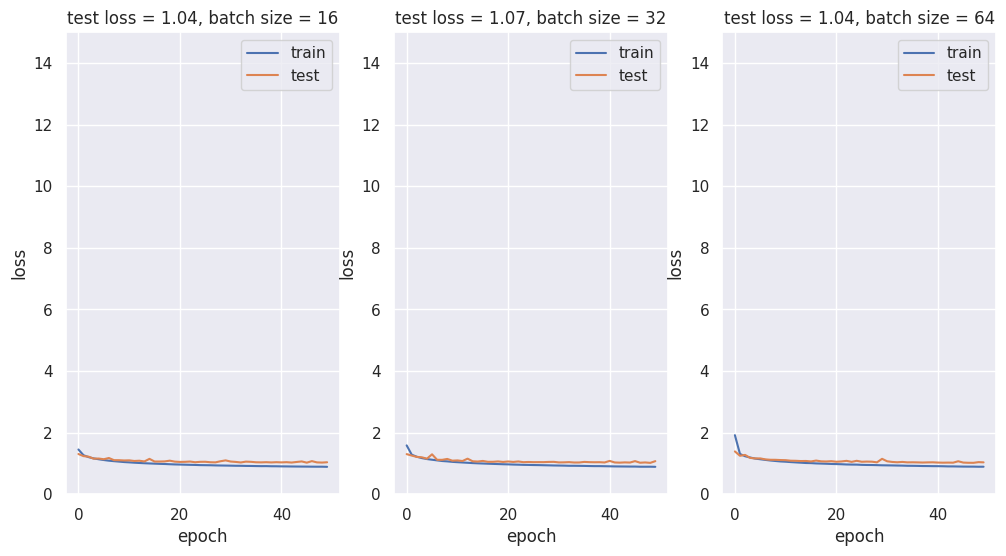

In [ ]:
# Plot
fig = plt.figure(figsize=(12, 6))
sns.set(color_codes=True)
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        np.array(list((x_train))).astype(float),
        y_train.values,
        batch_size=batch,
        validation_data=(np.array(list((x_test))).astype(float), y_test.values),
        verbose=0,
        epochs=nb_epoch,
    )
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.ylim((0, 15))
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()

14) This cell configures a ModelCheckpoint callback and trains the model while saving the best-performing weights. The saved file can later be loaded for evaluation and prediction without retraining.

In [ ]:
# Save the trained model
filepath = DATA / "best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    str(filepath),
    monitor="loss",
    verbose=0,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit the model
model.fit(
    np.array(list((x_train))).astype(float),
    y_train.values,
    epochs=nb_epoch,
    batch_size=16,
    callbacks=callbacks_list,
    verbose=0,
)

15) This cell evaluates the trained model on the test set and prints key regression metrics. These values summarize predictive performance after training.

In [ ]:
# Evalute the model
print(f"Evaluate the model on the test data")
scores = model.evaluate(np.array(list((x_test))), y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}")
print(f" mae: {scores[2]:.2f}")

Evaluate the model on the test data
 loss: 1.03
 mse (same as loss): 1.03
 mae: 0.81


16) This cell predicts pIC50 values for the held-out test molecules. The first few predictions are printed for a quick sanity check.

In [ ]:
# Predict pIC50 values on x_test data
y_pred = model.predict(np.array(list((x_test))))

# Print 5 first pIC50 predicted values
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

1523/1523 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
7.81
6.35
6.48
5.93
6.70


17) This cell plots predicted versus true pIC50 values on a scatter plot. The diagonal line indicates ideal agreement between prediction and experiment.

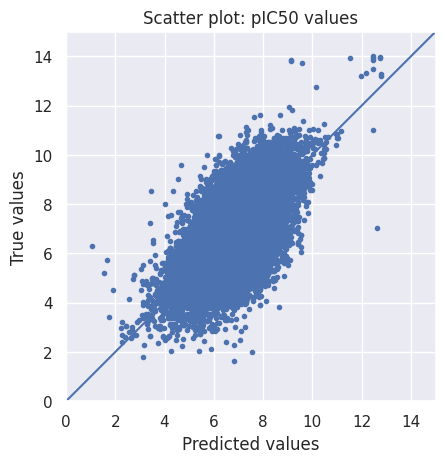

In [ ]:
# Scatter plot
limits = 0, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

18) This cell loads an external set of unlabeled compounds from a CSV file. These molecules are used as new candidates for model inference.

In [ ]:
# Load external/unlabeled data set
external_data = pd.read_csv(DATA / "test.csv", index_col=0)
external_data = external_data.reset_index(drop=True)
external_data.head()
# NBVAL_CHECK_OUTPUT

,SMILES
0,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...
1,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...
2,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...


19) This cell converts external SMILES strings into MACCS fingerprints and stores them in a new column. It aligns external inputs with the model's feature format.

In [ ]:
# Convert SMILES strings to MACCS fingerprints
external_data["fingerprints_df"] = external_data["SMILES"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe : ", external_data.shape)
external_data.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe :  (3, 2)


,SMILES,fingerprints_df
0,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


20) This cell runs pIC50 predictions on the external compounds and joins them back to the original external dataframe. The resulting table is previewed for inspection.

In [ ]:
# Prediction on external/unlabeled data
predictions = model.predict(
    np.array(list((external_data["fingerprints_df"]))).astype(float), callbacks=callbacks_list
)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = external_data.join(predicted_pIC50)

predicted_pIC50_df.head(5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


,SMILES,fingerprints_df,predicted_pIC50
0,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.212903
1,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.394145
2,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.793141


21) This cell saves the external prediction results to a CSV file in the data directory. This makes the predictions reusable outside the notebook.

In [ ]:
# Save the predicted values in a csv file in the data folder
predicted_pIC50_df.to_csv(DATA / "predicted_pIC50_df.csv")

22) This cell reloads the saved prediction file, ranks compounds by predicted pIC50, and keeps the top three candidates.

In [ ]:
# Select top 3 drugs
predicted_pIC50_df = pd.read_csv(DATA / "predicted_pIC50_df.csv", index_col=0)
top3_drug = predicted_pIC50_df.nlargest(3, "predicted_pIC50")
top3_drug

,SMILES,fingerprints_df,predicted_pIC50
0,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,6.212903
2,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,5.793141
1,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,5.394145


23) This cell renders molecular structures for the top-ranked candidates and annotates each with its predicted pIC50. It provides a visual summary of the final selected compounds.

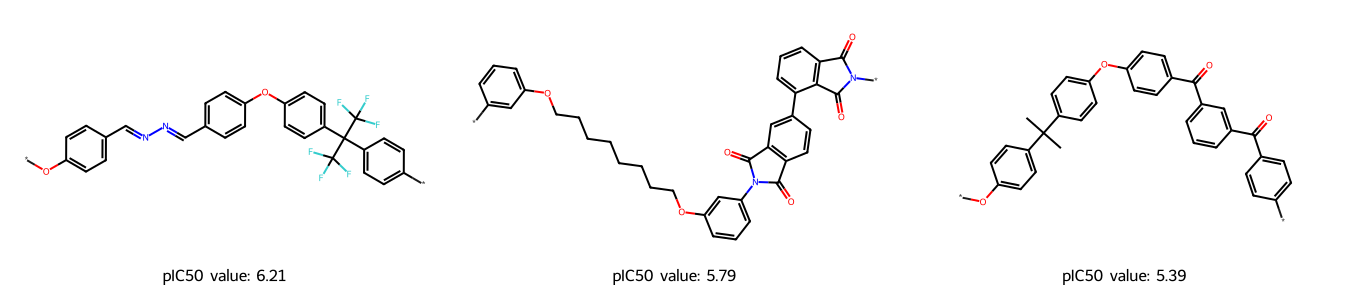

In [ ]:
# Draw the drug molecules
highest_pIC50 = predicted_pIC50_df["SMILES"][top3_drug.index]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [(f"pIC50 value: {value:.2f}") for value in pIC50_EGFR]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=pIC50_values)